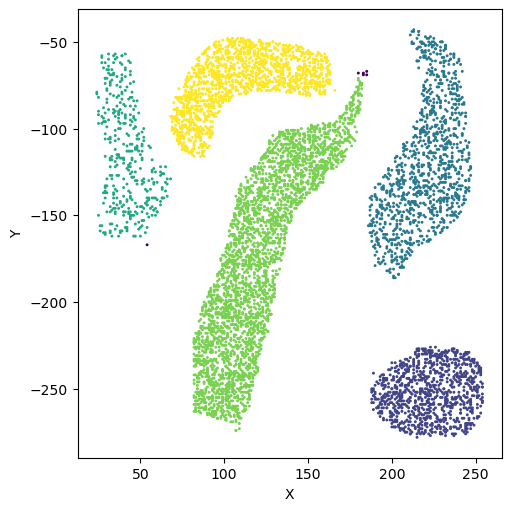

In [67]:
from sklearn.cluster import HDBSCAN
import numpy as np
import cv2
import pandas as pd
import os
import matplotlib.pyplot as plt

images = []
for file in os.listdir("images/"):
    if file.endswith(".jpg"):
        images.append("images/" + os.path.join(file))
davez = np.random.choice(images)
cl = HDBSCAN(store_centers="both",min_cluster_size=20, copy=True)
ima = cv2.imread(davez , cv2.IMREAD_GRAYSCALE)

ima_norm = (((255 - ima)) / ((255 - ima).sum()))

sum_coord = np.random.choice(a= ima.size, size=7000, p=ima_norm.flatten())

X = sum_coord%ima.shape[0]
Y = sum_coord//ima.shape[0]

data = pd.DataFrame([X,Y]).transpose()

cl.fit(data)
cl.labels_
events = {"x": X,
          "y": -Y,
          "c": cl.labels_}

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5*np.array(ima.shape)/max(ima.shape)), layout='constrained')
ax.scatter("x", "y", c="c",data=events, s=1.2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.savefig(str(davez).replace(".jpg", "_hdbscan.png"))
